In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df= pd.read_csv('fake_job_postings.csv')

In [4]:
df.head()

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   job_id               17880 non-null  int64 
 1   title                17880 non-null  object
 2   location             17534 non-null  object
 3   department           6333 non-null   object
 4   salary_range         2868 non-null   object
 5   company_profile      14572 non-null  object
 6   description          17879 non-null  object
 7   requirements         15184 non-null  object
 8   benefits             10668 non-null  object
 9   telecommuting        17880 non-null  int64 
 10  has_company_logo     17880 non-null  int64 
 11  has_questions        17880 non-null  int64 
 12  employment_type      14409 non-null  object
 13  required_experience  10830 non-null  object
 14  required_education   9775 non-null   object
 15  industry             12977 non-null  object
 16  func

In [6]:
df.describe()

,job_id,telecommuting,has_company_logo,has_questions,fraudulent
count,17880.000000,17880.000000,17880.000000,17880.000000,17880.000000
mean,8940.500000,0.042897,0.795302,0.491723,0.048434
std,5161.655742,0.202631,0.403492,0.499945,0.214688
min,1.000000,0.000000,0.000000,0.000000,0.000000
25%,4470.750000,0.000000,1.000000,0.000000,0.000000
50%,8940.500000,0.000000,1.000000,0.000000,0.000000
75%,13410.250000,0.000000,1.000000,1.000000,0.000000
max,17880.000000,1.000000,1.000000,1.000000,1.000000


In [8]:
df.shape

(17880, 18)

In [9]:
df.isnull().sum()

job_id                     0
title                      0
location                 346
department             11547
salary_range           15012
company_profile         3308
description                1
requirements            2696
benefits                7212
telecommuting              0
has_company_logo           0
has_questions              0
employment_type         3471
required_experience     7050
required_education      8105
industry                4903
function                6455
fraudulent                 0
dtype: int64

In [16]:
#dividing columns in categories that will help in data preprocessing 

In [17]:
text_columns = ['title', 'company_profile', 'description', 'requirements', 'benefits']
cat_columns = ['location', 'department', 'salary_range', 'employment_type',
               'required_experience', 'required_education', 'industry', 'function']
binary_columns = ['telecommuting', 'has_company_logo', 'has_questions']

In [21]:
#removing null values
for col in text_columns:
    df[col] = df[col].fillna('')
for col in cat_columns:
    df[col] = df[col].fillna('missing')
for col in binary_columns:
    df[col] = df[col].fillna(0)

In [23]:
#combining all the texts together 
df['full_text'] = df[text_columns].agg(' '.join, axis=1)

<Axes: xlabel='fraudulent', ylabel='count'>

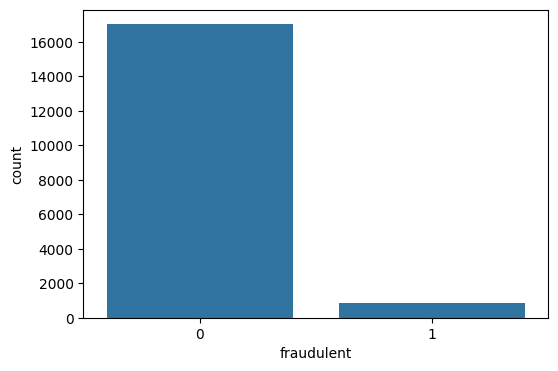

In [27]:
plt.figure(figsize=(6,4))
sns.countplot(x='fraudulent', data=df)

In [28]:
df.head()

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent,text,full_text
0,1,Marketing Intern,"US, NY, New York",Marketing,,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,,0,1,0,Other,Internship,,,Marketing,0,"Marketing Intern We're Food52, and we've creat...","Marketing Intern We're Food52, and we've creat..."
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,,Marketing and Advertising,Customer Service,0,Customer Service - Cloud Video Production 90 S...,Customer Service - Cloud Video Production 90 S...
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",,,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,,0,1,0,,,,,,0,Commissioning Machinery Assistant (CMA) Valor ...,Commissioning Machinery Assistant (CMA) Valor ...
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0,Account Executive - Washington DC Our passion ...,Account Executive - Washington DC Our passion ...
4,5,Bill Review Manager,"US, FL, Fort Worth",,,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0,Bill Review Manager SpotSource Solutions LLC i...,Bill Review Manager SpotSource Solutions LLC i...


In [30]:
df.duplicated().sum()

np.int64(0)

In [31]:
df["fraudulent"].value_counts()

fraudulent
0    17014
1      866
Name: count, dtype: int64

In [39]:
#nlp pre processing
import re
import string
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Bravima\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Bravima\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Bravima\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [36]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [37]:
def clean_text(text):
    # Lowercase
    text = text.lower()
    
    # Remove HTML tags
    text = re.sub(r'<[^>]+>', ' ', text)
    
    # Remove URLs
    text = re.sub(r'http[s]?://\S+', ' ', text)
    
    # Remove email addresses
    text = re.sub(r'\S+@\S+', ' ', text)
    
    # Remove punctuation and numbers
    text = re.sub(r'[^a-z\s]', ' ', text)
    
    # Tokenize
    tokens = word_tokenize(text)
    
    # Remove stopwords and lemmatize
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words and len(word) > 2]
    
    return ' '.join(tokens)

In [41]:
import nltk

nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Bravima\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


True

In [42]:
df['cleaned_text'] = df['full_text'].apply(clean_text)

In [43]:
df.head()

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,...,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent,text,full_text,cleaned_text
0,1,Marketing Intern,"US, NY, New York",Marketing,,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,,0,...,0,Other,Internship,,,Marketing,0,"Marketing Intern We're Food52, and we've creat...","Marketing Intern We're Food52, and we've creat...",marketing intern food created groundbreaking a...
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,...,0,Full-time,Not Applicable,,Marketing and Advertising,Customer Service,0,Customer Service - Cloud Video Production 90 S...,Customer Service - Cloud Video Production 90 S...,customer service cloud video production second...
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",,,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,,0,...,0,,,,,,0,Commissioning Machinery Assistant (CMA) Valor ...,Commissioning Machinery Assistant (CMA) Valor ...,commissioning machinery assistant cma valor se...
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,...,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0,Account Executive - Washington DC Our passion ...,Account Executive - Washington DC Our passion ...,account executive washington passion improving...
4,5,Bill Review Manager,"US, FL, Fort Worth",,,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,...,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0,Bill Review Manager SpotSource Solutions LLC i...,Bill Review Manager SpotSource Solutions LLC i...,bill review manager spotsource solution llc gl...


In [44]:
X_text = df['cleaned_text']
X_cat = df[cat_columns + binary_columns]
y = df['fraudulent']

In [45]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


In [46]:
#tfidf vectorization

In [48]:
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),        
    min_df=2,
    max_df=0.95
)

In [49]:
X_text_train, X_text_test, X_cat_train, X_cat_test, y_train, y_test = train_test_split(
    X_text, X_cat, y, test_size=0.2, random_state=42, stratify=y
)

In [50]:
X_text_train_tfidf = tfidf.fit_transform(X_text_train)
X_text_test_tfidf = tfidf.transform(X_text_test)

In [51]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=True), cat_columns),
        ('binary', 'passthrough', binary_columns)
    ]
)

In [52]:
X_cat_train_processed = preprocessor.fit_transform(X_cat_train)
X_cat_test_processed = preprocessor.transform(X_cat_test)

In [54]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [55]:
#combine td-idf + categorical columns

In [56]:
from scipy.sparse import hstack

In [57]:
X_train = hstack([X_text_train_tfidf, X_cat_train_processed])
X_test = hstack([X_text_test_tfidf, X_cat_test_processed])

# Convert to dense 
X_train_dense = X_train.toarray()
X_test_dense = X_test.toarray()

print("Final feature matrix shape:", X_train_dense.shape)

Final feature matrix shape: (14304, 9887)


In [59]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)
class_weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, class_weights))
print("Class weights:", class_weight_dict)

Class weights: {np.int64(0): np.float64(0.5254573506722504), np.int64(1): np.float64(10.32034632034632)}


In [60]:
#Building neural network

In [61]:
model = Sequential([
    Dense(512, activation='relu', input_shape=(X_train_dense.shape[1],)),
    Dropout(0.4),
    Dense(256, activation='relu'),
    Dropout(0.4),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

C:\Users\Bravima\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [62]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', 'Precision', 'Recall']
)

In [63]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 512)                 │       5,062,656 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 5,235,201 (19.97 MB)

 Trainable params: 5,235,201 (19.97 MB)

 Non-trainable params: 0 (0.00 B)

In [65]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    X_train_dense, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=64,
    class_weight=class_weight_dict,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 13s 75ms/step - Precision: 0.8384 - Recall: 0.9911 - accuracy: 0.9902 - loss: 0.0249 - val_Precision: 0.6588 - val_Recall: 0.8421 - val_accuracy: 0.9724 - val_loss: 0.1042
Epoch 2/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 9s 50ms/step - Precision: 0.8437 - Recall: 0.9929 - accuracy: 0.9906 - loss: 0.0242 - val_Precision: 0.7794 - val_Recall: 0.7970 - val_accuracy: 0.9801 - val_loss: 0.0809
Epoch 3/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 12s 66ms/step - Precision: 0.9143 - Recall: 0.9911 - accuracy: 0.9950 - loss: 0.0202 - val_Precision: 0.6975 - val_Recall: 0.8496 - val_accuracy: 0.9759 - val_loss: 0.0836
Epoch 4/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 15s 82ms/step - Precision: 0.9285 - Recall: 0.9964 - accuracy: 0.9961 - loss: 0.0114 - val_Precision: 0.8333 - val_Recall: 0.7895 - val_accuracy: 0.9829 - val_loss: 0.0951
Epoch 5/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 14s 79ms/step - Precision: 0.9807 - Recall: 1.0000 - accuracy: 0.9990 - loss: 0.0019 - val_Precision: 0.8281 - va

In [66]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

y_pred_prob = model.predict(X_test_dense)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("ROC AUC Score:", roc_auc_score(y_test, y_pred_prob))

112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      3403
           1       0.84      0.86      0.85       173

    accuracy                           0.99      3576
   macro avg       0.92      0.92      0.92      3576
weighted avg       0.99      0.99      0.99      3576

ROC AUC Score: 0.9884596895972441


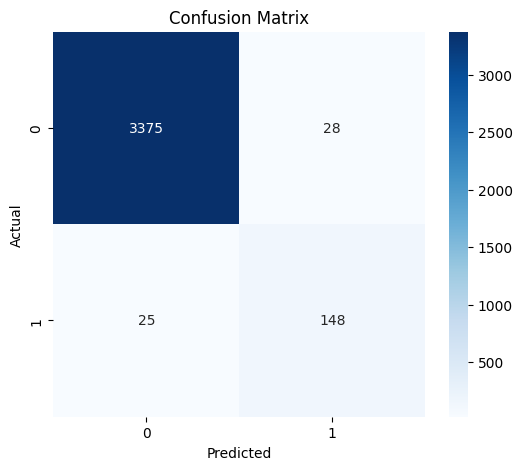

In [67]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [69]:
model.save('fraudulent_job_model.keras')
import joblib
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')
joblib.dump(preprocessor, 'categorical_preprocessor.pkl')

['categorical_preprocessor.pkl']

In [70]:
test_job = {
    'title': 'Data Entry Clerk - Work From Home $5000/week',
    'location': 'missing',
    'department': 'missing',
    'salary_range': 'missing',
    'company_profile': '',
    'description': 'Easy job! Just enter data from home and get paid big money every week. No experience needed.',
    'requirements': 'Must have computer and internet. Small registration fee to start.',
    'benefits': 'Unlimited earning potential! Be your own boss!',
    'telecommuting': 1,
    'has_company_logo': 0,
    'has_questions': 0,
    'employment_type': 'missing',
    'required_experience': 'missing',
    'required_education': 'missing',
    'industry': 'missing',
    'function': 'missing'
}

# Prediction function (uses already loaded model, tfidf, preprocessor)
def predict_single_job(job_dict):
    df_new = pd.DataFrame([job_dict])
    
    # Fill missing columns safely
    for col in text_columns:
        df_new[col] = df_new.get(col, '').fillna('')
    for col in cat_columns:
        df_new[col] = df_new.get(col, 'missing').fillna('missing')
    for col in binary_columns:
        df_new[col] = df_new.get(col, 0).fillna(0)
    
    # Combine and clean text
    df_new['full_text'] = df_new[text_columns].agg(' '.join, axis=1)
    df_new['cleaned_text'] = df_new['full_text'].apply(clean_text)
    
    # Vectorize
    text_vec = tfidf.transform(df_new['cleaned_text'])
    cat_vec = preprocessor.transform(df_new[cat_columns + binary_columns])
    X_new = hstack([text_vec, cat_vec]).toarray()
    
    # Predict
    prob = model.predict(X_new, verbose=0)[0][0]
    prediction = 'FRAUDULENT ⚠️' if prob > 0.5 else 'REAL ✅'
    
    return prob, prediction

# Run prediction
probability, result = predict_single_job(test_job)

print("\n=== SINGLE SAMPLE PREDICTION ===\n")
print(f"Job Title: {test_job['title']}")
print(f"Fraud Probability: {probability:.4f}")
print(f"Final Prediction : {result}")

if probability > 0.5:
    print("\n🚨 This job posting looks highly suspicious / likely fake!")
else:
    print("\n✅ This job posting appears legitimate.")


=== SINGLE SAMPLE PREDICTION ===

Job Title: Data Entry Clerk - Work From Home $5000/week
Fraud Probability: 0.9998
Final Prediction : FRAUDULENT ⚠️

🚨 This job posting looks highly suspicious / likely fake!
